# Python Tools & Libraries to be Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split   
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
##Data understanding

In [3]:
#loading the data from csv file to a pandas Dataframes
insurance_dataset = pd.read_csv(r'D:\COLLEGE BOOK\insurance (1).csv')

In [4]:
print(insurance_dataset)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900       0.0    yes  southwest  16884.92400
1      18    male  33.770       1.0     no  southeast   1725.55230
2      28    male  33.000       3.0     no  southeast   4449.46200
3      33    male  22.705       0.0     no  northwest  21984.47061
4      32    male  28.880       0.0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970       3.0     no  northwest  10600.54830
1334   18  female  31.920       0.0     no  northeast   2205.98080
1335   18  female  36.850       0.0     no  southeast   1629.83350
1336   21  female  25.800       0.0     no  southwest   2007.94500
1337   61  female  29.070       0.0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [5]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0.0,yes,southwest,16884.92400
1,18,male,33.770,1.0,no,southeast,1725.55230
2,28,male,33.000,3.0,no,southeast,4449.46200
3,33,male,22.705,0.0,no,northwest,21984.47061
4,32,male,28.880,0.0,no,northwest,3866.85520


In [6]:
insurance_dataset.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3.0,no,northwest,10600.5483
1334,18,female,31.92,0.0,no,northeast,2205.9808
1335,18,female,36.85,0.0,no,southeast,1629.8335
1336,21,female,25.80,0.0,no,southwest,2007.9450
1337,61,female,29.07,0.0,yes,northwest,29141.3603


In [7]:
# number of rows and columns
insurance_dataset.shape

(1338, 7)

In [8]:
insurance_dataset.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [9]:
# get some information about dataset
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1334 non-null   float64
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 73.3+ KB


In [10]:
# Exploratory Data Analysis (EDA)

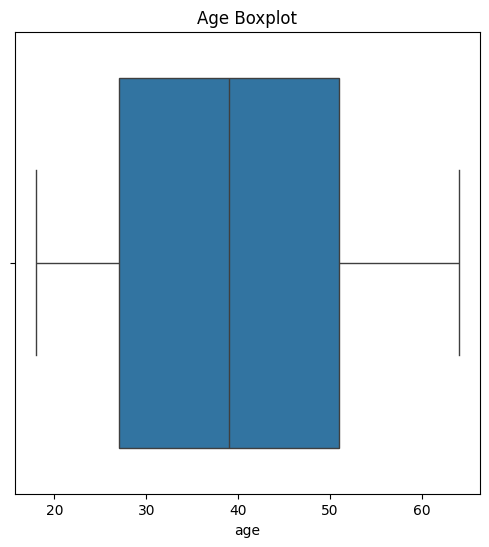

In [11]:
# Univarient Analysis:
plt.figure(figsize=(6,6))
sns.boxplot(x=insurance_dataset['age'])
plt.title('Age Boxplot')
plt.show()

In [12]:
# Bivariate Analysis

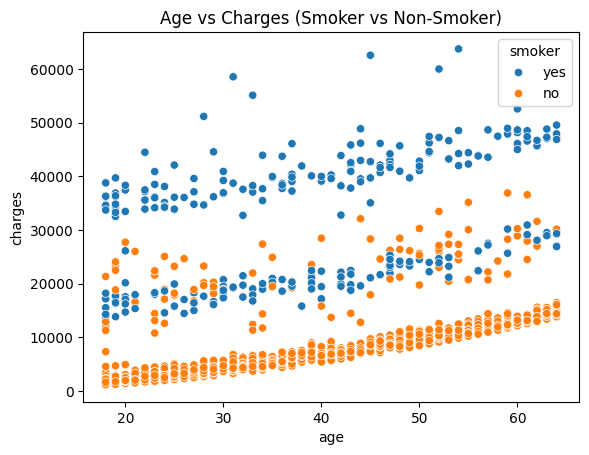

In [13]:
plt.figure()
sns.scatterplot(x="age", y="charges", hue="smoker", data=insurance_dataset)
plt.title("Age vs Charges (Smoker vs Non-Smoker)")
plt.show()

In [14]:
# Multivarient anayst.

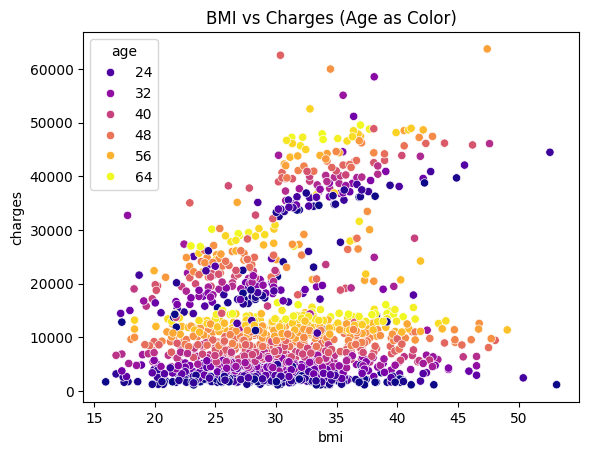

In [15]:
plt.figure()
sns.scatterplot(x="bmi",
                y="charges",
                hue="age",
                palette="plasma",
                data=insurance_dataset)

plt.title("BMI vs Charges (Age as Color)")
plt.show()

In [16]:
# Handling Missing Data and Outliers

In [17]:
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    4
smoker      0
region      0
charges     0
dtype: int64

In [18]:
(insurance_dataset.isnull().sum() / len(insurance_dataset)) * 100

age         0.000000
sex         0.000000
bmi         0.000000
children    0.298954
smoker      0.000000
region      0.000000
charges     0.000000
dtype: float64

In [19]:
insurance_dataset['children'] = insurance_dataset['children'].fillna(insurance_dataset['children'].median())

In [20]:
print(insurance_dataset['children'])

0       0.0
1       1.0
2       3.0
3       0.0
4       0.0
       ... 
1333    3.0
1334    0.0
1335    0.0
1336    0.0
1337    0.0
Name: children, Length: 1338, dtype: float64


In [21]:
median_value = insurance_dataset['children'].median()
print("Median used to fill missing values:", median_value)

Median used to fill missing values: 1.0


In [22]:
print(insurance_dataset['children'])

0       0.0
1       1.0
2       3.0
3       0.0
4       0.0
       ... 
1333    3.0
1334    0.0
1335    0.0
1336    0.0
1337    0.0
Name: children, Length: 1338, dtype: float64


In [23]:
insurance_dataset['children'].mode()

0    0.0
Name: children, dtype: float64

In [24]:
## categorical data: 
 ##> sex
## > smoker
## > Region

In [25]:
#Data analyst

In [26]:
# Spread of Data

In [27]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.097907,13270.422265
std,14.049960,6.098187,1.204012,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


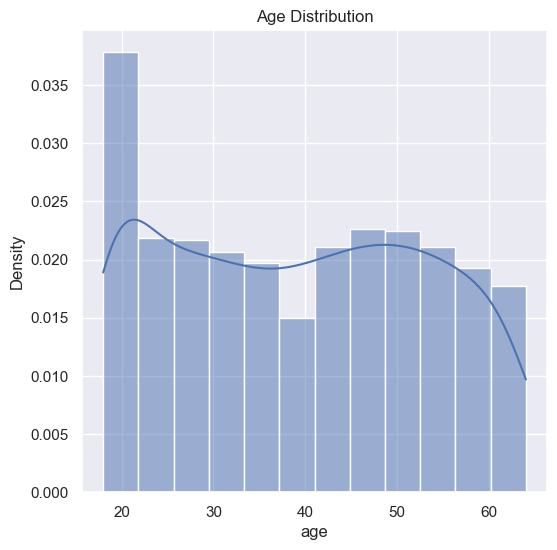

In [28]:
sns.set()
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['age'],kde=True, stat="density")
plt.title('Age Distribution')
plt.xlabel("age")
plt.show()


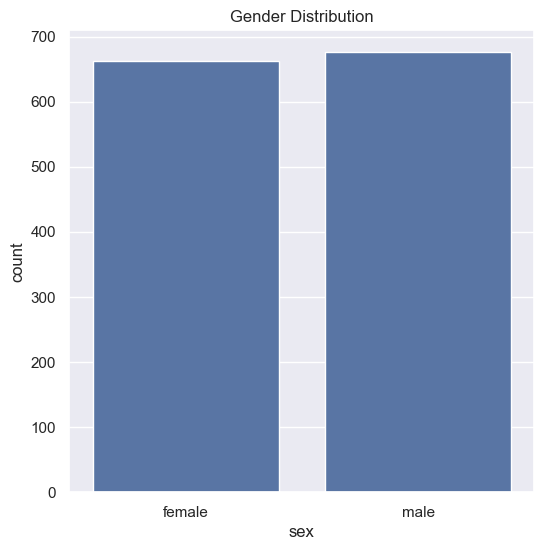

In [29]:
# gender column
plt.figure(figsize=(6,6))
sns.countplot(x='sex', data=insurance_dataset)
plt.title('Gender Distribution')
plt.show()

In [30]:
insurance_dataset['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

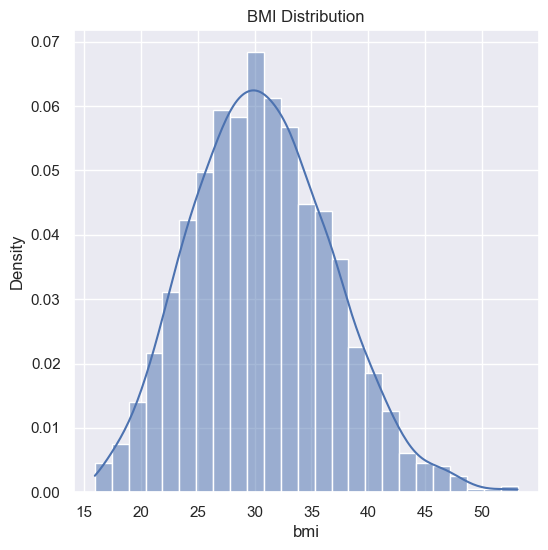

In [31]:
# bmi distribution 
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['bmi'],kde=True, stat="density")
plt.title('BMI Distribution')
plt.show()

In [32]:
#NORMAL BMI = 18.5 TO 24.9

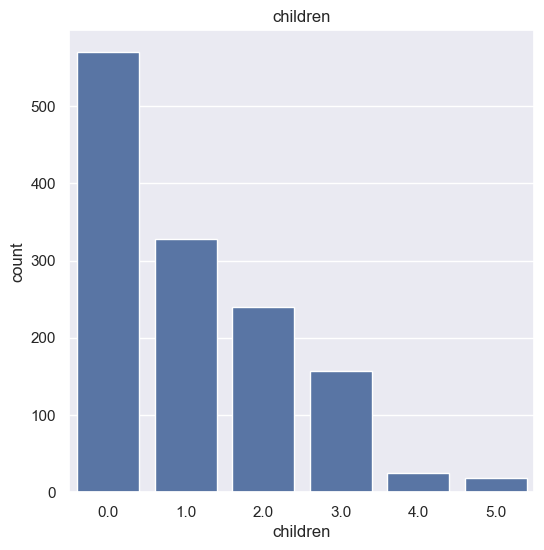

In [33]:
# CHILDREN COLUMN 
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=insurance_dataset)
plt.title('children')
plt.show()

In [34]:
insurance_dataset['children'].value_counts()

children
0.0    570
1.0    328
2.0    240
3.0    157
4.0     25
5.0     18
Name: count, dtype: int64

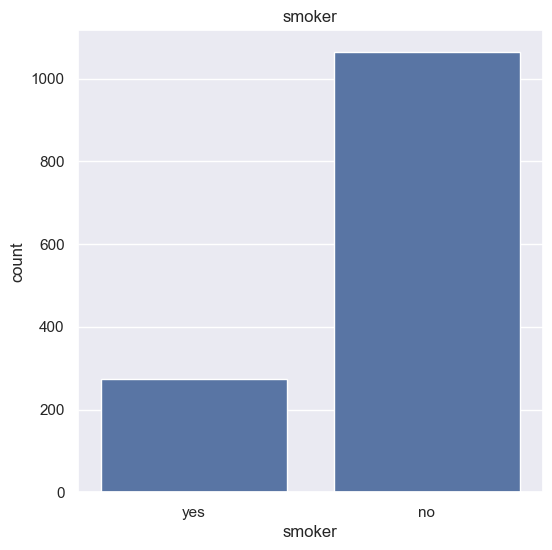

In [35]:
# smoker column
plt.figure(figsize=(6,6))
sns.countplot(x='smoker', data=insurance_dataset)
plt.title('smoker')
plt.show()

In [36]:
insurance_dataset['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

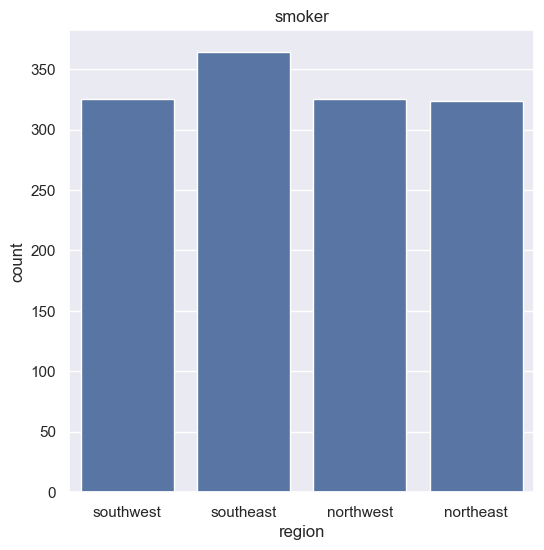

In [37]:
# region column
plt.figure(figsize=(6,6))
sns.countplot(x='region', data=insurance_dataset)
plt.title('smoker')
plt.show()

In [38]:
insurance_dataset['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

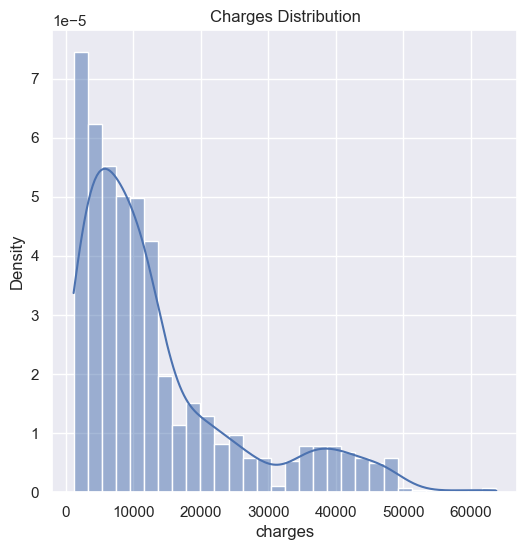

In [39]:
# Charges distribution 
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset['charges'],kde=True, stat="density")
plt.title('Charges Distribution')
plt.show()

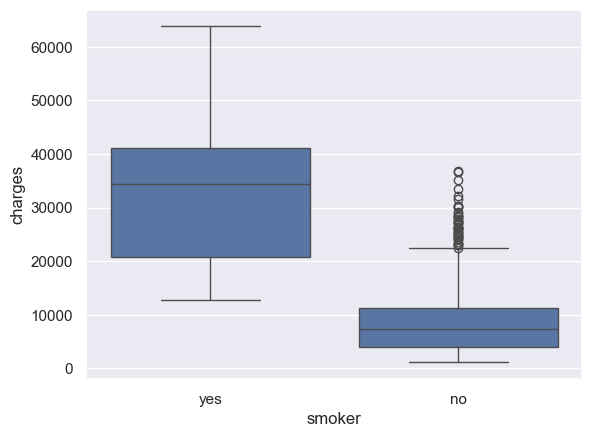

In [40]:
sns.boxplot(x='smoker', y='charges', data=insurance_dataset)
plt.show()

In [41]:
# Data Pre-Processing 

In [42]:
#Encoding the categorical feature.

In [43]:
# Encoding sex column 
insurance_dataset.replace({'sex':{'male':0,'female':1}}, inplace=True)
# Encoding sex column 
insurance_dataset.replace({'smoker':{'yes':0,'no':1}}, inplace=True)
# encoding 'region' column 
insurance_dataset.replace({'region':{'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3}},inplace=True)

C:\Users\91635\AppData\Local\Temp\ipykernel_5908\2612381431.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex':{'male':0,'female':1}}, inplace=True)
C:\Users\91635\AppData\Local\Temp\ipykernel_5908\2612381431.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'smoker':{'yes':0,'no':1}}, inplace=True)
C:\Users\91635\AppData\Local\Temp\ipykernel_5908\2612381431.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To

In [44]:
#splitting the feature and Target

In [45]:
x = insurance_dataset.drop(columns='charges', axis=1)#1 represent columns 
y = insurance_dataset['charges']

In [46]:
print(x)

      age  sex     bmi  children  smoker  region
0      19    1  27.900       0.0       0       1
1      18    0  33.770       1.0       1       0
2      28    0  33.000       3.0       1       0
3      33    0  22.705       0.0       1       3
4      32    0  28.880       0.0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970       3.0       1       3
1334   18    1  31.920       0.0       1       2
1335   18    1  36.850       0.0       1       0
1336   21    1  25.800       0.0       1       1
1337   61    1  29.070       0.0       0       3

[1338 rows x 6 columns]


In [47]:
print(y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [48]:
#splitting the data into training data & testing data

In [49]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [50]:
print(x.shape, x_train.shape , x_test.shape)

(1338, 6) (1070, 6) (268, 6)


In [51]:
#Model training 

In [52]:
#linear Regression

In [53]:
regressor = LinearRegression()

In [54]:
# loading the Linear Regression model
regressor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# model training

In [65]:
training_data_prediction = regressor.predict(x_train)

In [ ]:
# R square value

In [68]:
r2_train = metrics.r2_score(y_train, training_data_prediction)
print(r2_train)

0.7514458645680917


In [71]:
test_data_prediction = regressor.predict(x_test)

In [72]:
r2_test = metrics.r2_score(y_test, test_data_prediction)
print(r2_test)

0.7447857495627832


In [ ]:
# Building a predicitive system